# 0. Antes de empezar

Definimos aquí algunas funciones y clases que utilizaremos en esta Notebook

In [1]:
pip install rasterio

In [2]:
# Funciones para extraer muestras de la notebook anterior:
from rasterio.mask import mask

def extraer_muestras(imagen, poligonos_externos, valor_relleno, columnas = ["Band_0", "Band_1", "Band_2", "Band_3", "Band_4", "Band_5"]):
    muestras_extraidas = pd.DataFrame()
    for i, pol in poligonos_externos.iterrows():
        clip, _ = mask(dataset=imagen, shapes=[pol.geometry], crop=True, nodata=valor_relleno)
        d, x, y = clip.shape
        clip = clip.reshape([d, x * y]).T
        clip = pd.DataFrame(clip, columns=columnas)
        clip = clip[(clip != valor_relleno).all(axis=1)]
        clip['Clase'] = pol['Clase']
        clip['DESC'] = pol['DESC']
        clip['Rect_ID'] = i + 1
        muestras_extraidas = pd.concat([muestras_extraidas, clip], ignore_index=True)
    return muestras_extraidas

In [3]:
# Funciones de visualización de la notebook anterior:

def escalar_imagen(imagen, p, nodata = None):
  # Calcular los percentiles p y 100-p
  valor_min = np.percentile(imagen[imagen != nodata], p)
  valor_max = np.percentile(imagen[imagen != nodata], 100-p)

  # Truncar la imagen al rango [p1, p99]
  ecualizada = np.clip(imagen, valor_min, valor_max)

  # Normalizar la imagen al rango 0-255.
  ecualizada = (ecualizada - valor_min) / (valor_max - valor_min) * 255

  # Convertir la imagen ecualizada a entero de 8 bits
  ecualizada = np.uint8(ecualizada)

  # Retornar la imagen ecualizada
  return ecualizada

def escalar_imagen_multibanda(imagen, p, nodata = None):
  # Crear un array vacio con la misma estructura que imagen_spot_apilada
  imagen_escalada = np.empty_like(imagen)

  # Definir una variable con el número de canales
  canales = imagen_escalada.shape[-1]

  # Escalar una a una las bandas (usando p)
  for i in range(canales):
    canal = imagen[:, :, i]
    imagen_escalada[:, :, i] = escalar_imagen(canal, p, nodata = nodata)

  # Convertir a np.uint8 el array escalado (no hace falta seguir usando float)
  imagen_escalada = np.uint8(imagen_escalada)

  return imagen_escalada

In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
import io
from shapely.geometry import box
import rasterio
import rasterio.transform
from matplotlib import pyplot as plt

# Notebook 03b: Entrenamiento de modelos y clasificación supervisada

Esta segunda Notebook la dedicaremos a tomar las muestras generadas anteriormente, traducirlas en el $X$ e $Y$ que necesita un clasificador supervidado, y entrenar distintos clasificadores, junto a la evaluación de su desempeño. Finalizaremos generando mapas de clasificación para toda la imagen.

### Datos con los que trabajaremos en esta notebook:

- Recorte de la misma Sentinel que cada uno generó en la Clase 02 (`s2_clip.tif`). Lo descargamos en una celda que está mas abajo en esta misma Notebook.
- Archivo CSV con las muestras generadas en la Notebook 03a. Si no tienen su propio archivo, pueden trabajar con [este achivo de ejemplo](https://drive.google.com/file/d/1XOz9YQCuPLaIt-PdeR0oK0Vqz3zI6ouM/view?usp=drive_link).

## 1. Lectura de las muestras, generación de los datos X e Y

### 1.1. Separación en $X$ e $Y$

Lo primero que debemos hacer es abrir nuestro CSV con las muestras, y luego ver qué columnas representas las variables que conforman el conjunto $X$, y cuál será la etiqueta o $Y$:



In [6]:
muestras = pd.read_csv('muestras.csv')
muestras.head()

,Unnamed: 0,Band_0,Band_1,Band_2,Band_3,Band_4,Band_5,DESC,Rect_ID,Clase
0,0,1082,1170,706,477,347,252,Agua,1,0
1,1,1068,1187,697,493,342,280,Agua,1,0
2,2,1064,1182,705,500,342,280,Agua,1,0
3,3,1063,1174,704,501,334,291,Agua,1,0
4,4,1070,1176,708,496,334,291,Agua,1,0


$X$ estará conformado por las columnas `['Band_0', 'Band_1', 'Band_2', 'Band_3', 'Band_4', 'Band_5']` que contienen las reflectancias de las bandas de la imagen Sentinel-2. $Y$ es la clase a predecir, para lo cual nos quedaremos solo con la columna `Clase`:



In [7]:
X = muestras[['Band_0', 'Band_1', 'Band_2', 'Band_3', 'Band_4', 'Band_5']]
Y = muestras['Clase']

A continuación, vamos a separar a ambos conjuntos en subconjuntos de entrenamiento y validación. Para ello, tenemos que importar `train_test_split` desde la librería Scikit-Learn:



In [8]:
from sklearn.model_selection import train_test_split

A esta función le debemos pasar como argumento:
- Los datos $X$ e $Y
- Si queremos estatrificar los datos (`stratify`). Esto es muy útil cuando tenemos clases desbalanceadas. En tal caso, al construirse los conjuntos de _train_ y _test_ se respetará la proporción de las clases originales.
- Proporción del conjunto de _test_, entre 0 y 1. Típicamente se asignan valores entre 0.2 y 0.3.
- Si se quieren "barajar" o mezclar los datos (`shuffle`). Esto es últil también dado que los datos vienen ordenados o agrupados en el _DataFrame_ por rectángulo o polígono. Esto ayuda a garantizar que se tomen datos distribuidos en todos los polígonos.
- Si queremos que esta división sea replicable, podemos pasarle una semilla con `random_state`.



In [9]:
# Realizamos la división de los datos para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, test_size=0.25, random_state=42, shuffle=True)

print(f'Tamaño de y_train: {y_train.shape}')
print(f'Tamaño de y_test: {y_test.shape}')

Tamaño de y_train: (1758,)
Tamaño de y_test: (587,)


## Entrenamiento de modelos - Random Forest

En esta sección veremos cómo entrenar y evaluar las métricas de error para el último algoritmo visto en clase, _Random Forest_ o simplemente _RF_.

### 2.1. Entrenamiento del modelo

Empezamos por importar `RandomForestClassifier` desde `sklearn.ensemble`:



In [10]:
from sklearn.ensemble import RandomForestClassifier

A continuación, vamos a instanciar un clasificador _RF_ estableciendo valores para los parámetros `max_depth` y `n_estimators`, que se refieren a la máxima profundidad y la cantidad de árboles, respectivamente. Utilizaremos un valor de profundidad de 10 y una cantidad de 100 árboles



In [11]:
# Instanciamos el clasificador
rf_classifier = RandomForestClassifier(max_depth=10, n_estimators = 100)

El siguiente paso es entrenarlo con los datos de entrenamiento: `X_train, y_train`



In [12]:
# Entrenamos el clasificador
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

### 2.2. Matriz de confusión y métricas de error

A continuación, debemos evaluar el ajuste de este clasificador sobre nuestros datos de prueba. Para empezar, podemos empezar por construir la matriz de confusión. La **matriz de confusión** es una herramienta para evaluar el rendimiento de un modelo de clasificación. Muestra la cantidad de predicciones correctas e incorrectas del modelo en cada clase, permitiendo analizar errores y calcular métricas como la precisión, el _recall_ y el _F1-score_.



In [13]:
from sklearn.metrics import confusion_matrix

# Realizamos la predicción
y_pred_rf = rf_classifier.predict(X_test)

# Calculamos la matriz de confusión
m_rf = confusion_matrix(y_test, y_pred_rf)

Como `m_rf` es un `array` en 2 dimensiones, podemos visualizarlo más gráficamente como si fuera una imagen, usando la función `ConfusionMatrixDisplay` de `sklearn`.



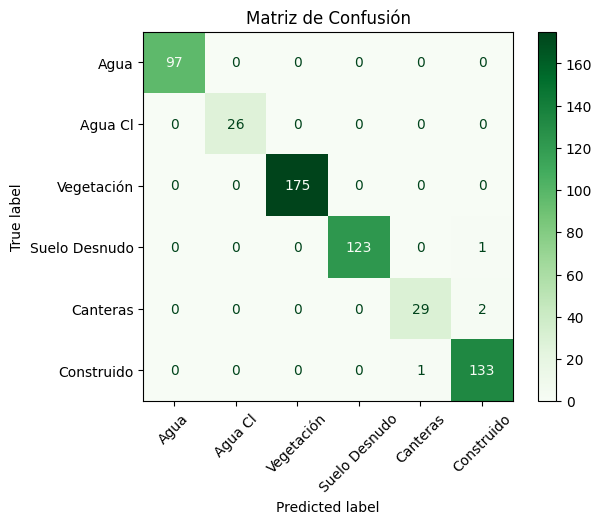

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

# Etiquetas de clase
labels = ['Agua', 'Agua Cl', 'Vegetación', 'Suelo Desnudo', 'Canteras', 'Construido']

# Visualizar matriz de confusión con etiquetas
disp = ConfusionMatrixDisplay(confusion_matrix=m_rf, display_labels=labels)
disp.plot(cmap='Greens', xticks_rotation=45)
plt.title("Matriz de Confusión")
plt.show()

### 2.3. Métricas de error

Como dijimos antes, a partir de la matriz, podemos calcular ciertas métricas de error, que se basan en el conteo de los siguientes grupos. Cuando tenemos más de dos clases, la matriz de confusión es de **N × N** (siendo N el número de clases). Las métricas de evaluación como **Precisión (Precision), Recall (Exhaustividad) y F1-score** deben calcularse para cada clase individualmente y luego promediarse. Para entender estos grupos, supongamos que tenemos una clasificación binaria (2 clases, A y B), y analizamos los resultados en función de la clase A:

| **Clase Real \ Predicha** | Pred A | Pred B |
| ------------------------- | ------ | ------ |
| **Clase A (Real)**        | TP     | FN     |
| **Clase B (Real)**        | FP     | TN     |

* **TP (True Positive):** Casos de **Clase A** correctamente clasificados como **A**.
* **FN (False Negative):** Casos de **Clase A** que el modelo clasificó erróneamente como **B**.
* **FP (False Positive):** Casos de **Clase B** que el modelo clasificó erróneamente como **A**.
* **TN (True Negative):** Casos de **Clase B** correctamente clasificados como **B**.

&nbsp;

La **precisión** mide cuántos de los elementos predichos como una clase específica eran realmente de esa clase. Por ejemplo: De todas las veces que el modelo predijo Vegetación, ¿cuántas eran realmente Vegetación?  --> Esto está relacionado con lo que en Teledetección se conoce como **error de comisión** ($1 - Precisión$).

$$
\text{Precisión}(i) = \frac{TP(i)}{TP(i) + FP(i)}
$$

&nbsp;

El **recall** mide cuántos de los elementos reales de una clase fueron detectados correctamente. Por ejemplo: De todos los casos reales de Agua, ¿cuántos fueron detectados correctamente como Agua? --> Esto está relacionado con lo que en Teledetección se conoce como **error de omisión** ($1 - recall$).

$$
\text{Recall} (i) = \frac{TP(i)}{TP(i) + FN(i)}
$$


&nbsp;

  
El **F1-score** es la media armónica entre precisión y recall. Por ejemplo, si la clase Suelo Desnudo tiene precisión alta pero _recall_ bajo, significa que el modelo es muy preciso cuando dice que algo es Suelo Desnudo, pero se le escapan o está omitiendo muchos casos reales de Suelo Desnudo.

$$
F1(i) = 2 \times \frac{\text{Precisión}(i) \times \text{Recall}(i)}{\text{Precisión}(i) + \text{Recall}(i)}
$$

Por último, de la matriz  de confusión se suele calcular la exactitud global o _accuracy_ en inglés, que mide mide la proporción de aciertos totales sobre el total de casos. Esto nos permite tener una evaluación general de cómo le fue a nuestro clasificador.

$$
\text{Exactitud global} = \frac{\sum_i a_{ii}}{\text{Total de muestras}}
$$

&nbsp;


Para ver estas métricas, podemos usar `classification_report(y_test, y_pred)`, así como también `accuracy_score`:



In [15]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, y_pred_rf))
print(f'Precisión global: {accuracy_score(y_test, y_pred_rf):.3f}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        97
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00       175
           3       1.00      0.99      1.00       124
           4       0.97      0.94      0.95        31
           5       0.98      0.99      0.99       134

    accuracy                           0.99       587
   macro avg       0.99      0.99      0.99       587
weighted avg       0.99      0.99      0.99       587

Precisión global: 0.993


### 2.4. Búsqueda del valor óptimo de profundidad

Podemos hacer un análisis de cómo impacta el valor del parámetro `max_depth` en la performance del `Random Forest`. Para ello, en la siguiente celda se prueban distintos modelos `RF` variando el valor de este hiperparámetro, y se van almacenando los resultados en dos `arrays` que se llaman `resultados_test_RF` y `resultados_train_RF`, y se calcula una métrica denominada `cross_val_score`. Esta métrica viene del concepto de validación cruzada, una técnica muy utilizada, que consiste en repetir muchas veces el experimento de separar los datos en `train` y `test` y evaluar la predicción para cada valor de el/los parámetros. Luego se promedia y se ve cómo fue el desempeño promedio para cada elección del/los parámetros.

<img src="https://drive.google.com/uc?id=1ni4vZHdCcxROfVJvGzjhgE-5DOBpOYE-" width="600">



In [16]:
from sklearn.model_selection import cross_val_score

lmd = np.arange(2,20) # Generamos un vector con valores de 2 a 19
resultados_test_RF = np.zeros(len(lmd)) # Generamos un array para guardar los resultados de test
resultados_train_RF = np.zeros(len(lmd)) # Generamos un array para guardar los resultados de train

# Vamos evaluando el modelo variando el valor de max_depth
for md_idx, md in enumerate(lmd):
  print(f'  Probando con max_depth = {md}')
  clf = RandomForestClassifier(max_depth=md, random_state = 42, n_estimators = 100)
  clf.fit(X_train, y_train)
  Y_pred_test_  = clf.predict(X_test)
  Y_pred_train_ = clf.predict(X_train)
  resultados_test_RF[md_idx]  = cross_val_score(clf, X_test, y_test, cv=5).mean()
  resultados_train_RF[md_idx] = cross_val_score(clf, X_train, y_train, cv=5).mean()

  Probando con max_depth = 2
  Probando con max_depth = 3
  Probando con max_depth = 4
  Probando con max_depth = 5
  Probando con max_depth = 6
  Probando con max_depth = 7
  Probando con max_depth = 8
  Probando con max_depth = 9
  Probando con max_depth = 10
  Probando con max_depth = 11
  Probando con max_depth = 12
  Probando con max_depth = 13
  Probando con max_depth = 14
  Probando con max_depth = 15
  Probando con max_depth = 16
  Probando con max_depth = 17
  Probando con max_depth = 18
  Probando con max_depth = 19


Ahora tenemos los resultados de evaluar el modelo tanto con entrenamiento como sobre validación, en las variables `resultados_test_RF` y `resultados_train_RF`. Podemos buscar cuál fue el mejor resultado, para qué valor de profundidad, y podemos plotear todas las pruebas en un solo gráfico:







El mejor resultado en el conjunto de testeo fue obtenido para un RF de profundidad 6 y una exactitud de 0.991


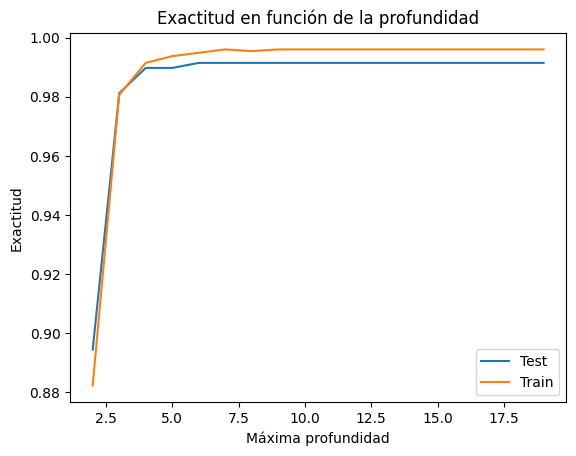

In [17]:
# Busco el mejor resultado
imx = np.argmax(resultados_test_RF)
best_prof = lmd[imx]
best_acc = resultados_test_RF[imx]
print(f'El mejor resultado en el conjunto de testeo fue obtenido para un RF de profundidad {best_prof} y una exactitud de {best_acc:.3f}')

# Grafico promedios
plt.plot(lmd,resultados_test_RF,label="Test")
plt.plot(lmd,resultados_train_RF,label="Train")
plt.title("Exactitud en función de la profundidad")
plt.ylabel("Exactitud")
plt.xlabel("Máxima profundidad")
# plt.axvline(x=best_prof, label='Mejor profundidad', c='r')
plt.legend()
plt.show()

## 3. Clasificación de la imagen

Una vez que tenemos entrenados nuestros clasficadores, y que estamos conformes con los parámetros (o hiper-parámetros) utilizados para entrenarlos, los podemos aplicar a la imagen completa, para lo cual debemos abrirla, _romper_ su estructrua espacial para que sea equiparable al _DataFrame_ de muestras, y aplicarle el clasificador. Luego, podremos reconstruir la estructura de la imagen y guardarla como un archivo clasificado y georreferenciado.

Lo primero que hacemos es abrir la imagen como siempre y leer sus metadatos:



In [18]:
import gdown

# ID del archivo de Google Drive
file_id = "1i5OEwoHtuVWLMagae3RjY2jxRqr55Ctl"
url = f"https://drive.google.com/uc?id={file_id}"

# Descargar la imagen
output = "s2_clip.tif"
gdown.download(url, output, quiet=False)

# Abrimos la imagen y leemos sus metadatos
s2_clip = rasterio.open('s2_clip.tif')
metadatos = s2_clip.meta

# La pasammos a array de Numpy
s2_clip_bandas = s2_clip.read()

Downloading...
From: https://drive.google.com/uc?id=1i5OEwoHtuVWLMagae3RjY2jxRqr55Ctl
To: /content/s2_clip.tif
100%|██████████| 1.56M/1.56M [00:00<00:00, 28.7MB/s]


### 3.1. Romper la estructura espacial de la imagen

Para aplicar nuestros clasificadores, tenemos que redimensionar su estructura pra que sea igual al conjunto $X$, _rompiendo_ su parte espacial. La estructura final debería ser `(x*y, d)`, donde $x,y$ son las filas y columnas, y $d$ son las bandas:



In [19]:
# Leemos las dimensiones de la imagen
d,x,y = s2_clip_bandas.shape

# La redimensionamos
s2_clip_bandas_reshape = s2_clip_bandas.reshape([d, x * y]).T

# Verificamos las nuevas dimensiones
print('Dimensiones nuevas: ', s2_clip_bandas_reshape.shape)

Dimensiones nuevas:  (129930, 6)


### 3.2. Aplicar el clasificador sobre la imagen

A continuación, usamos `predict` como hicimos antes, pero en lugar de hacerlo sobre `X_test` lo hacemos sobre `s2_clip_bandas`.



Probablemente nos aparezca este mensaje: `UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names`. No es un error, sino una advertencia, porque el clasificador fue entrenado con un `DataFrame`, pero nosotros le estamos pasando un `array` sin nombres de columna. Nos conviene trabajar así para que luego sea más fácil reconstruir el mapa clasificado.

In [20]:
# Hacemos la predicción
img_pred_rf = rf_classifier.predict(s2_clip_bandas_reshape)

# Vemos las simensiones de la predicción y los valores únicos
print('Dimensiones: ', img_pred_rf.shape)
print('Valores únicos', np.unique(img_pred_rf))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Dimensiones:  (129930,)
Valores únicos [0 1 2 3 4 5]


### 3.3. Reconstruir el mapa clasificado

El `array`resultante tiene una sola dimensión, que corresponde a la cantidad total de píxeles $x*y$, así que lo podemos _resordenar_ como si fuera una imagen, pero ahora de un solo canal, es que el mapa clasificado:



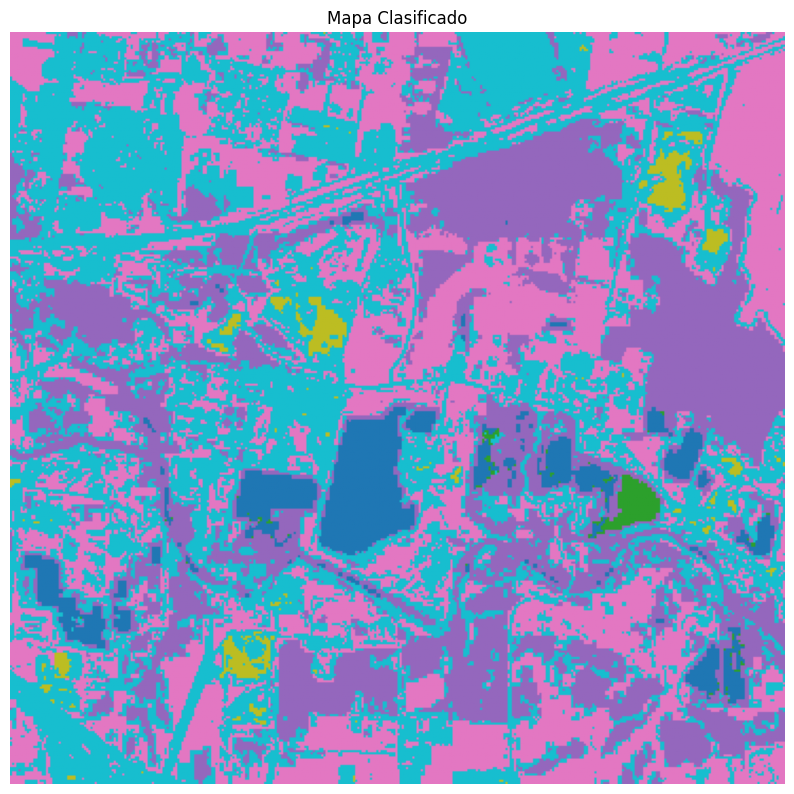

In [21]:
# Redimensionamos para que vuelva a tener estructura espacial
img_pred_rf = img_pred_rf.reshape(x, y)

# Ploteamos el resultado
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(img_pred_rf, cmap='tab10')
ax.set_title("Mapa Clasificado")
ax.axis("off")

plt.show()

### 3.4. Guardar el mapa clasificado

Podemos guardar esta clasificación como un archivo GeoTiff. Para eso, tenemos que alterar los metadatos, dato que ahora la imagen a guardar tiene una sola banda o canal. Entonces, podemos crear una copia de `metadatos`, y modificar esa información. Además, como ahora `0` es un valor posible de clase, podemos cambiar el valor de ``nodata` en los metadatos. Por ejemplo, podemos pasarle `np.iinfo(np.uint16).max`, que nos da 65535. Luego, procedemos a guardar la imagen con `rasterio`:



In [22]:
# Generar los metadatos para guardar la clasificación
metadatos_clasif = metadatos.copy()
metadatos_clasif['count'] = 1
metadatos_clasif['nodata'] = np.iinfo(np.uint16).max

# Guardar la clasificación
with rasterio.open("img_pred_rf.tif", 'w', **metadatos_clasif) as dst:
    dst.write(np.expand_dims(img_pred_rf, axis=0))

### Ejercicio

Aplicá el clasificador de _RF_ probando otros valores de profundidad sobre la imagen entera y guardá el archivo clasificado como GeoTiff (repetí los pasos que hicimos: Intanciar el clasificador, entrenarlo, y predecir los píxeles clasificados sobre toda la imagen).

## 4. Yapa: Prueba con un recorte de otra zona de la imagen y con muestras independientes

A continuación, vamos a abrir un recorte de otra zona de la misma imagen, junto a un archivo vectorial de muestras generado para esa zona. Utilizaremos estas muestras como conjunto de de validación externo para tener una segunda evaluación de nuestros modelos.



In [23]:
import gdown

# ------------- Imagen -----------

# ID del archivo de Google Drive
file_id = "1bGrDQLaG0qSDn4Uh3sBteHr9-RVLiGnt"
url = f"https://drive.google.com/uc?id={file_id}"

# Descargar la imagen
output = "recorte2_s2.tif"
gdown.download(url, output, quiet=False)

# Abrimos la imagen y leemos sus metadatos
s2_recorte2 = rasterio.open('recorte2_s2.tif')
metadatos_recorte2 = s2_recorte2.meta

# La pasammos a array de Numpy
s2_recorte2_bandas = s2_recorte2.read()

# ------------- Vectores -----------

# ID del archivo de Google Drive
file_id = "17C6UTyWbdZzaOh7qwcFxkdaJ-7nbA4LC"
url = f"https://drive.google.com/uc?id={file_id}"

# Descargar los vectores
output = "muestras_recorte2.gpkg"
gdown.download(url, output, quiet=False)

poligonos_externos = gpd.read_file(output)

Downloading...
From: https://drive.google.com/uc?id=1bGrDQLaG0qSDn4Uh3sBteHr9-RVLiGnt
To: /content/recorte2_s2.tif
100%|██████████| 1.14M/1.14M [00:00<00:00, 41.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=17C6UTyWbdZzaOh7qwcFxkdaJ-7nbA4LC
To: /content/muestras_recorte2.gpkg
100%|██████████| 106k/106k [00:00<00:00, 54.9MB/s]


Tenemos muestras de solamente 5 clases: Agua, Vegetación, Suelo Desnudo, Canteras y Construcciones, ya que no hay agua con Clorofila en esta parte de la imagen.



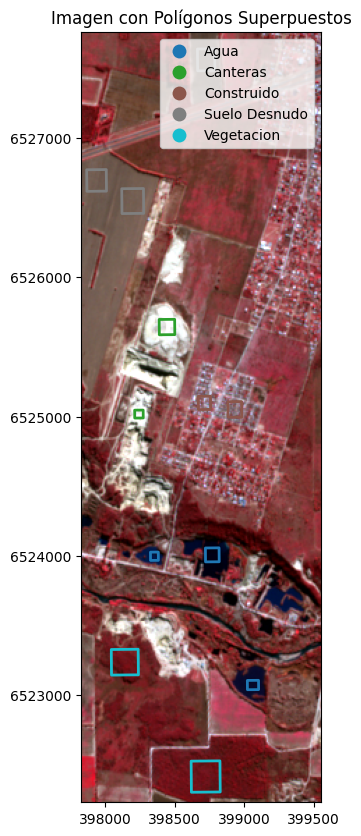

In [24]:
left, bottom, right, top = s2_recorte2.bounds  # Extraer los límites

# Escalar la imagen
s2_recorte2_bandas_escalado = escalar_imagen_multibanda(s2_recorte2_bandas.transpose(1,2,0), 1)

# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(10, 10))

# Mostrar la imagen con los límites geoespaciales
ax.imshow(s2_recorte2_bandas_escalado[:, :, [3, 2, 1]], extent=[left, right, bottom, top], origin="upper")
ax.ticklabel_format(style="plain", axis="y")

# Agregar los polígonos
poligonos_externos.plot(ax=ax, facecolor='none', column = 'DESC', linewidth=2, legend = True)

ax.set_title("Imagen con Polígonos Superpuestos")

plt.show()

A continuación, podemos repetir el procedimiento hecho en la Notebook 03a, para extraer un _DataFrame_ de muestras usando los polígonos y la imagen. Utilizaremos la función `extraer_muestras``que traemos desde antes:

```python
muestras_extraidas = extraer_muestras(s2_recorte2, poligonos_externos, valor_relleno = 65535)
```

In [25]:
muestras_extraidas = extraer_muestras(s2_recorte2, poligonos_externos, valor_relleno = 65535)

A continuación, separamos nuestros datos en $X$ y $Y$. Esta vez no hacemos la división en $X_{train},X_{test}$ e $Y_{train},Y_{test}$, ya que usaremos toda la información para validar nuestros modelo. Veamos cómo le va al modelo _RF_



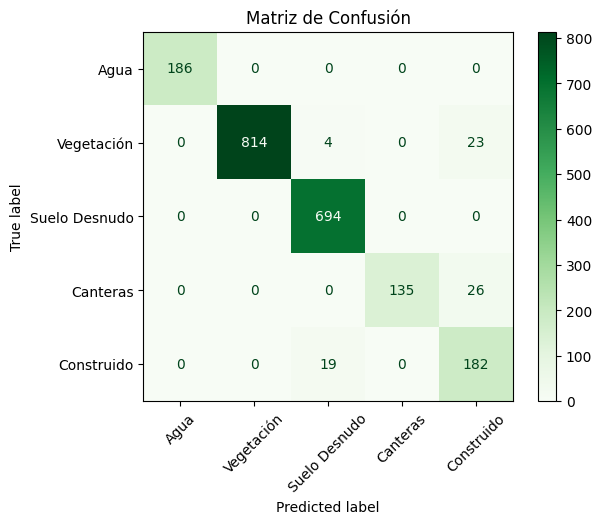

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       186
           2       1.00      0.97      0.98       841
           3       0.97      1.00      0.98       694
           4       1.00      0.84      0.91       161
           5       0.79      0.91      0.84       201

    accuracy                           0.97      2083
   macro avg       0.95      0.94      0.94      2083
weighted avg       0.97      0.97      0.97      2083

Precisión global: 0.965


In [26]:
# Dividimos en X e Y
X_recorte2 = muestras_extraidas[['Band_0', 'Band_1', 'Band_2', 'Band_3', 'Band_4', 'Band_5']]
Y_recorte2 = muestras_extraidas['Clase']

# Realizamos la predicción
y_pred_rf_recorte2 = rf_classifier.predict(X_recorte2)

# Calculamos la matriz de confusión
m_rf_recorte2 = confusion_matrix(Y_recorte2, y_pred_rf_recorte2)

# Ploteamos la matriz
# Definir las etiquetas
labels = ['Agua', 'Vegetación', 'Suelo Desnudo', 'Canteras', 'Construido']

# Visualizar matriz de confusión con etiquetas
disp = ConfusionMatrixDisplay(confusion_matrix=m_rf_recorte2, display_labels=labels)
disp.plot(cmap='Greens', xticks_rotation=45)
plt.title("Matriz de Confusión")
plt.show()

print(classification_report(Y_recorte2, y_pred_rf_recorte2))

acc = accuracy_score(Y_recorte2, y_pred_rf_recorte2)
print(f'Precisión global: {acc:.3f}')

Finalmente, al igual que lo hicimos con el primer recorte, podemos generar el mapa clasificado:



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


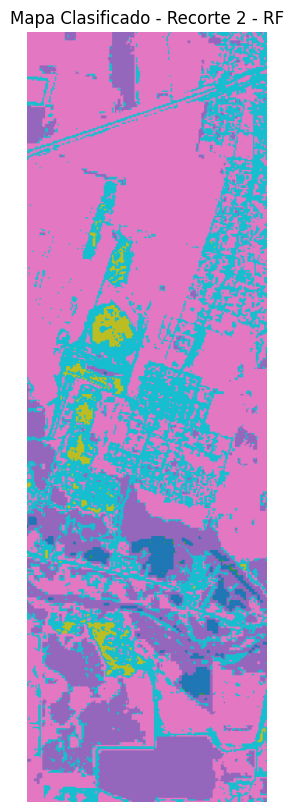

In [27]:
# Leemos las dimensiones de la imagen
d,x,y = s2_recorte2_bandas.shape

# La redimensionamos
s2_recorte2_bandas_reshape = s2_recorte2_bandas.reshape([d, x * y]).T

# Hacemos la predicción
img_pred_rf_recorte2 = rf_classifier.predict(s2_recorte2_bandas_reshape)

# Redimensionamos para que vuelva a tener estructura espacial
img_pred_rf_recorte2 = img_pred_rf_recorte2.reshape(x,y)


# Ploteamos el resultado
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(img_pred_rf_recorte2, cmap='tab10')
ax.set_title("Mapa Clasificado - Recorte 2 - RF")
ax.axis("off")

plt.show()

### Ejercicio

Generá y guardá el mapa clasificado con _RF_ sobre este nuevo recorte, como archivos GeoTiff. Los metadatos de la imagen de este recorte fueron leidos a la variable `metadatos_reocrte2.`. Podés adaptar ese diccionario para contemplar la cantidad de bandas y el valor _nodato_ para el archivo clasificado.